# Práctica: Submuestreo, sobremuestreo y manejo de desbalance de clases

**Curso:** Machine Learning — Posgrado UTEC  
**Tema:** Submuestreo aleatorio, sobremuestreo aleatorio, Tomek Links, SMOTE y su impacto en clasificadores  


## Integrantes del grupo (máximo 4)

| # | Nombre completo |
|:---:|:---:|
| 1 |Fernando Gutiérrez|

---

## Objetivo

Alcanzar un **F1-Score ≥ 0.65** sobre la **clase minoritaria (diabéticos)** en el conjunto de test, utilizando combinaciones de técnicas de remuestreo y clasificadores.

## Clasificadores requeridos

| Clasificador | Documentación |
|---|---|
| K-Nearest Neighbors | [sklearn KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) |
| Regresión Logística | [sklearn LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) |
| Support Vector Machine | [sklearn SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) |
| Naive Bayes | [sklearn GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) |

## Técnicas de remuestreo requeridas

| Técnica | Tipo | Documentación |
|---|---|---|
| Submuestreo aleatorio | Submuestreo | [imblearn RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html) |
| Tomek Links | Submuestreo informado | [imblearn TomekLinks](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.TomekLinks.html) |
| Sobremuestreo aleatorio | Sobremuestreo | [imblearn RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html) |
| SMOTE | Sobremuestreo sintético | [imblearn SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) |
| SMOTE + Tomek Links | Combinado | [imblearn SMOTETomek](https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTETomek.html) |
| Sin remuestreo | Baseline | — |

## Comparación de técnicas de muestreo

| Aspecto | Sub. aleatorio | Sobre. aleatorio |
|---|---|---|
| Información | Pierde datos | No pierde |
| Overfitting | Bajo | Alto |
| Datos nuevos | No | No (copias) |
| Complejidad | O(1) | O(1) |
| Tamaño final | Pequeño | Grande |
| Ruido | No agrega | Puede amplificar |

## ¿Cuándo usar cada técnica?

| Escenario | Recomendación |
|---|---|
| Dataset muy grande | Submuestreo aleatorio |
| Dataset pequeño | Sobremuestreo aleatorio |
| Frontera de decisión ruidosa | Submuestreo con Tomek Links |
| Muchas características | Submuestreo aleatorio |
| Desbalance moderado | Sobremuestreo aleatorio |
| Necesidad de interpretabilidad | Submuestreo (datos reales) |

## Pipeline correcto

```
Datos originales → Train/Test Split → Evaluar desbalance → [Muestreo SOLO en Train] → Entrenar → Evaluar con F1, AUC en Test original
```

**Regla de oro:** El muestreo se aplica **solo al conjunto de entrenamiento**. El conjunto de test debe mantener la distribución original para una evaluación realista.

## Reglas

1. El remuestreo se aplica **únicamente al conjunto de entrenamiento**
2. La evaluación se realiza sobre el **conjunto de test original** (sin remuestrear)
3. El F1-Score objetivo es sobre la **clase 1** (diabéticos)
4. Deben completar **todas** las celdas marcadas con `# TODO`

---
## Fase 0: Instalación de dependencias

Ejecutar esta celda para instalar las librerías necesarias.

- [`imbalanced-learn`](https://imbalanced-learn.org/stable/): Librería para técnicas de remuestreo
- [`scikit-learn`](https://scikit-learn.org/stable/): Clasificadores y métricas
- [`matplotlib`](https://matplotlib.org/): Visualización

In [ ]:
#!pip install imbalanced-learn scikit-learn matplotlib pandas numpy -q

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

# Métricas
# Docs: https://scikit-learn.org/stable/modules/model_evaluation.html
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Preprocesamiento
# Docs: https://scikit-learn.org/stable/modules/preprocessing.html
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Clasificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Remuestreo
# Docs: https://imbalanced-learn.org/stable/references/index.html
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Umbral objetivo
F1_OBJETIVO = 0.65

print("Dependencias cargadas correctamente.")
print(f"F1-Score objetivo (clase minoritaria): {F1_OBJETIVO}")

Dependencias cargadas correctamente.
F1-Score objetivo (clase minoritaria): 0.65


---
## Fase 1: Descarga y exploración del dataset

### Dataset: Pima Indians Diabetes

Este dataset contiene información médica de **768 mujeres** de la comunidad Pima (Arizona, EE.UU.) para predecir si padecen **diabetes**.

| Feature | Descripción |
|---|---|
| `Pregnancies` | Número de embarazos |
| `Glucose` | Concentración de glucosa en plasma (mg/dL) |
| `BloodPressure` | Presión arterial diastólica (mm Hg) |
| `SkinThickness` | Espesor del pliegue cutáneo del tríceps (mm) |
| `Insulin` | Insulina sérica a 2 horas (mu U/mL) |
| `BMI` | Índice de masa corporal |
| `DiabetesPedigreeFunction` | Función de pedigrí de diabetes |
| `Age` | Edad (años) |
| **`Outcome`** | **0 = No diabética, 1 = Diabética** |

**Fuente:** [UCI Machine Learning Repository](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

**Desbalance:** Aproximadamente **65% clase 0** (no diabética) vs **35% clase 1** (diabética)

In [74]:
# ============================================================
# DESCARGA AUTOMÁTICA DEL DATASET
# ============================================================
# No modificar esta celda

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columnas = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]
df = pd.read_csv(url, header=None, names=columnas)

print(f"Dataset descargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nDistribución de la variable objetivo (Outcome):")
print(df['Outcome'].value_counts())
print(f"\nPorcentaje de diabéticas (clase 1): {df['Outcome'].mean()*100:.1f}%")
df.head()

Dataset descargado: 768 filas × 9 columnas

Distribución de la variable objetivo (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

Porcentaje de diabéticas (clase 1): 34.9%


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 1.1 Exploración básica

**Guía:** Analicen las estadísticas descriptivas del dataset. Observen si hay valores sospechosos (e.g., `Glucose=0`, `BloodPressure=0`) que podrían ser datos faltantes codificados como cero.

Recurso útil: [pandas `describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

In [75]:
# TODO: Mostrar estadísticas descriptivas del dataset
# Pista: usar df.describe()
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [76]:
df.shape

(768, 9)

In [77]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer

In [78]:
# Imputamos con MICE solo las columnas donde 0 representa dato faltante

columnas_relevantes = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

def imputar_con_mice(dataframe, columnas, random_state=42, max_iter=20):
    """Imputa con MICE los ceros tratados como valores faltantes en columnas seleccionadas.

    Args:
        dataframe (pd.DataFrame): DataFrame original que contiene las variables a imputar.
        columnas (list[str]): Columnas donde el valor 0 debe reemplazarse por NaN antes de imputar.
        random_state (int): Semilla para reproducibilidad del algoritmo IterativeImputer.
        max_iter (int): Numero maximo de iteraciones del proceso MICE.

    Returns:
        pd.DataFrame: Copia del DataFrame con las columnas seleccionadas imputadas.
    """
    df_imputado = dataframe.copy()
    df_imputado[columnas] = df_imputado[columnas].replace(0, np.nan)

    imputer = IterativeImputer(
        random_state=random_state,
        max_iter=max_iter,
        initial_strategy='median'
    )
    df_imputado[columnas] = imputer.fit_transform(df_imputado[columnas])
    return df_imputado

df_filtered = imputar_con_mice(df, columnas_relevantes, random_state=RANDOM_STATE)

pd.DataFrame({
    'ceros_antes': (df[columnas_relevantes] == 0).sum(),
    'faltantes_despues': df_filtered[columnas_relevantes].isna().sum()
})

,ceros_antes,faltantes_despues
Glucose,5,0
BloodPressure,35,0
SkinThickness,227,0
Insulin,374,0
BMI,11,0


In [79]:
df_filtered.shape

(768, 9)

In [80]:
df_filtered.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.647422,72.381264,28.773335,151.788820,32.443149,0.471876,33.240885,0.348958
std,3.369578,30.460089,12.129658,9.530197,97.418473,6.880563,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,-25.296791,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,89.901729,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.071887,130.000000,32.097206,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,35.000000,188.722342,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 1.2 Visualización del desbalance

**Guía:** Crear un gráfico de barras que muestre la distribución de la clase objetivo. Esto les ayudará a dimensionar visualmente el desbalance.

Recurso útil: [matplotlib `bar()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)

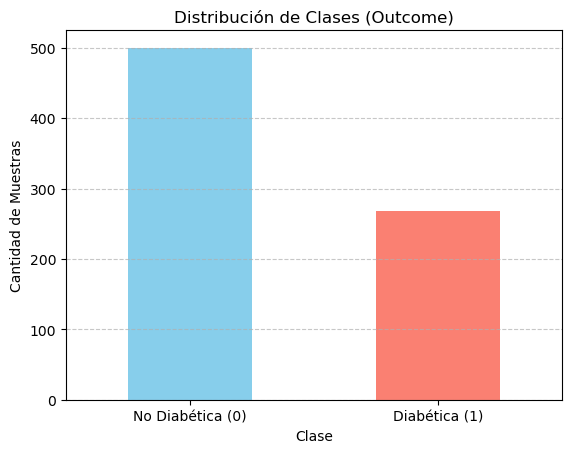

In [81]:
# TODO: Crear un gráfico de barras con la distribución de clases
# Pista: usar df['Outcome'].value_counts().plot(kind='bar', ...)
# Usar colores distintos para cada clase
df_filtered['Outcome'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'], rot=0)
plt.title('Distribución de Clases (Outcome)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Muestras')
plt.xticks(ticks=[0, 1], labels=['No Diabética (0)', 'Diabética (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---
## Fase 2: Preprocesamiento

**Guía:**
1. Separar features (`X`) y target (`y`)
2. Dividir en train/test con `test_size=0.3` y `stratify=y`
3. Escalar las features con `StandardScaler` (fit solo en train, transform en ambos)

**Importante:** El escalado se ajusta **solo** con los datos de entrenamiento para evitar data leakage.

Recursos útiles:
- [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

In [82]:
# TODO: Separar features y target
X = df_filtered.drop('Outcome', axis=1)
y = df_filtered['Outcome']


# TODO: Dividir en train/test (70/30), estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# TODO: Escalar features (fit en train, transform en ambos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Verificar distribución
print(f"Train: {Counter(y_train)}")
print(f"Test:  {Counter(y_test)}")

Train: Counter({0: 350, 1: 187})
Test:  Counter({0: 150, 1: 81})


---
## Fase 3: Baseline (sin remuestreo)

**Guía:** Entrenar los 4 clasificadores **sin ningún remuestreo** y registrar sus métricas. Este será el punto de referencia contra el cual medirán las mejoras.

**Pregunta para reflexionar:** ¿Qué métrica es más relevante en un problema de diagnóstico médico: accuracy o recall? ¿Por qué?

Recursos útiles:
- [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)

In [83]:
# Función auxiliar para evaluar un clasificador (NO MODIFICAR)
def evaluar(nombre, y_true, y_pred):
    """Evalúa y retorna las métricas de un clasificador."""
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (1)': precision_score(y_true, y_pred),
        'Recall (1)': recall_score(y_true, y_pred),
        'F1 (1)': f1_score(y_true, y_pred)
    }

In [84]:
# TODO: Entrenar los 4 clasificadores SIN remuestreo y recopilar métricas

clasificadores = {
    'KNN':       KNeighborsClassifier(n_neighbors=10),
    'Logística':  LogisticRegression(max_iter=1000, random_state=42),
    'SVM':       SVC(random_state=42),
    'Naive Bayes': GaussianNB()
}

resultados_baseline = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    resultados_baseline.append(evaluar(f'{nombre} (baseline)', y_test, y_pred))

df_baseline = pd.DataFrame(resultados_baseline).round(4)
df_baseline


,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN (baseline),0.7489,0.6885,0.5185,0.5915
1,Logística (baseline),0.7403,0.6615,0.5309,0.5890
2,SVM (baseline),0.7359,0.6667,0.4938,0.5674
3,Naive Bayes (baseline),0.7359,0.6250,0.6173,0.6211


### 3.1 Reflexión sobre el baseline

**Preguntas guía (responder en la celda siguiente):**

1. ¿Cuál clasificador tiene el mejor F1 sobre la clase 1 sin remuestreo?
2. ¿Alguno supera el objetivo de F1 ≥ 0.65? Si no, ¿qué tan lejos están?
3. ¿Observan diferencia entre accuracy y F1? ¿A qué se debe?
4. ¿Qué significa un recall bajo en el contexto de diagnóstico de diabetes?

**Respuestas:**

1. Naive Bayes
2. No, ninguno
3. Si hay diferencia. Se debe al desbalance entre las clases: el accuracy no es la mejor métrica para estos casos. Es mejor considerar el F1-score sobre todo cuando se trata de datos médicos.
4. Significa un alto número de falsos negativos lo cual no es deseable para aplicaciones en medicina. 

---
## Fase 4: Experimentación con técnicas de submuestreo

El submuestreo reduce la clase mayoritaria para equilibrar las clases. Veremos dos variantes:
- **Submuestreo aleatorio:** elimina muestras de la clase mayoritaria al azar
- **Tomek Links:** elimina selectivamente pares de puntos de clases opuestas que son mutuamente vecinos más cercanos, limpiando la frontera de decisión

### 4.1 Submuestreo aleatorio

**Guía:** El submuestreo aleatorio **elimina** muestras de la clase mayoritaria hasta igualar la minoritaria. La desventaja es la pérdida de información potencialmente útil.

**Pregunta para reflexionar:** ¿Qué pasa con la cantidad total de datos de entrenamiento tras el submuestreo? ¿Cómo podría afectar esto al rendimiento?

Recurso útil: [RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html)

In [85]:
# TODO: Aplicar submuestreo aleatorio al conjunto de entrenamiento

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print(f"Antes:   {Counter(y_train)} → Total: {len(y_train)}")
print(f"Después: {Counter(y_train_rus)} → Total: {len(y_train_rus)}")


Antes:   Counter({0: 350, 1: 187}) → Total: 537
Después: Counter({0: 187, 1: 187}) → Total: 374


In [95]:
# TODO: Entrenar los 4 clasificadores con datos submuestreados
# Evaluar en X_test_scaled (sin remuestrear)

resultados_rus = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_rus, y_train_rus)
    y_pred = clf.predict(X_test_scaled)
    resultados_rus.append(evaluar(f'{nombre} + Sub. aleatorio', y_test, y_pred))

df_rus = pd.DataFrame(resultados_rus).round(4)
df_rus


,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + Sub. aleatorio,0.7359,0.6111,0.6790,0.6433
1,Logística + Sub. aleatorio,0.7489,0.6292,0.6914,0.6588
2,SVM + Sub. aleatorio,0.7749,0.6408,0.8148,0.7174
3,Naive Bayes + Sub. aleatorio,0.7229,0.5955,0.6543,0.6235


### 4.2 Submuestreo con Tomek Links

**Guía:** Dos puntos $(\mathbf{x}_i, \mathbf{x}_j)$ de clases distintas forman un **Tomek Link** si no existe un tercer punto $\mathbf{x}_k$ tal que:

$$d(\mathbf{x}_i, \mathbf{x}_k) < d(\mathbf{x}_i, \mathbf{x}_j) \quad \text{o} \quad d(\mathbf{x}_j, \mathbf{x}_k) < d(\mathbf{x}_i, \mathbf{x}_j)$$

Al eliminar el punto de la clase mayoritaria en cada Tomek Link, se limpia la frontera de decisión sin eliminar datos aleatoriamente.

Recurso útil: [TomekLinks](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.TomekLinks.html)

In [86]:
# TODO: Aplicar Tomek Links al conjunto de entrenamiento
#
tomek = TomekLinks()
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train_scaled, y_train)

print(f"Antes:   {Counter(y_train)} → Total: {len(y_train)}")
print(f"Después: {Counter(y_train_tomek)} → Total: {len(y_train_tomek)}")
print(f"Tomek Links eliminados: {len(y_train) - len(y_train_tomek)}")


Antes:   Counter({0: 350, 1: 187}) → Total: 537
Después: Counter({0: 316, 1: 187}) → Total: 503
Tomek Links eliminados: 34


In [87]:
# TODO: Entrenar los 4 clasificadores con datos limpiados por Tomek Links
# Evaluar en X_test_scaled (sin remuestrear)
#
resultados_tomek = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_tomek, y_train_tomek)
    y_pred = clf.predict(X_test_scaled)
    resultados_tomek.append(evaluar(f'{nombre} + Tomek Links', y_test, y_pred))
#
df_tomek = pd.DataFrame(resultados_tomek).round(4)
df_tomek


,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + Tomek Links,0.7619,0.6970,0.5679,0.6259
1,Logística + Tomek Links,0.7403,0.6479,0.5679,0.6053
2,SVM + Tomek Links,0.7359,0.6389,0.5679,0.6013
3,Naive Bayes + Tomek Links,0.7403,0.6265,0.6420,0.6341


---
## Fase 5: Experimentación con técnicas de sobremuestreo

El sobremuestreo incrementa la clase minoritaria para equilibrar las clases. Veremos dos variantes:
- **Sobremuestreo aleatorio:** duplica muestras existentes de la clase minoritaria
- **SMOTE:** genera muestras *sintéticas* por interpolación entre puntos minoritarios y sus K vecinos más cercanos

### 5.1 Sobremuestreo aleatorio

**Guía:** El sobremuestreo aleatorio simplemente **duplica** muestras existentes de la clase minoritaria. No agrega información nueva y puede causar sobreajuste, ya que el modelo memoriza los pocos ejemplos minoritarios.

Recurso útil: [RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html)

In [88]:
# TODO: Aplicar sobremuestreo aleatorio al conjunto de entrenamiento
#
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

print(f"Antes:   {Counter(y_train)} → Total: {len(y_train)}")
print(f"Después: {Counter(y_train_ros)} → Total: {len(y_train_ros)}")


Antes:   Counter({0: 350, 1: 187}) → Total: 537
Después: Counter({1: 350, 0: 350}) → Total: 700


In [89]:
# TODO: Entrenar los 4 clasificadores con datos sobremuestreados
# Evaluar en X_test_scaled (sin remuestrear)
#
resultados_ros = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_ros, y_train_ros)
    y_pred = clf.predict(X_test_scaled)
    resultados_ros.append(evaluar(f'{nombre} + Sobre. aleatorio', y_test, y_pred))

df_ros = pd.DataFrame(resultados_ros).round(4)
df_ros


,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + Sobre. aleatorio,0.7403,0.6296,0.6296,0.6296
1,Logística + Sobre. aleatorio,0.7532,0.6463,0.6543,0.6503
2,SVM + Sobre. aleatorio,0.7446,0.6375,0.6296,0.6335
3,Naive Bayes + Sobre. aleatorio,0.7316,0.6092,0.6543,0.6310


### 5.2 Sobremuestreo con SMOTE

**Guía:** SMOTE genera muestras sintéticas interpolando entre puntos minoritarios y sus K vecinos más cercanos:

$$\mathbf{x}_{\text{new}} = \mathbf{x}_i + \lambda \cdot (\hat{\mathbf{x}}_i - \mathbf{x}_i), \quad \lambda \sim U(0,1)$$

A diferencia del sobremuestreo aleatorio, SMOTE **genera datos nuevos** que no son copias exactas, lo que reduce el riesgo de overfitting.

Parámetro clave: `k_neighbors` (por defecto 5). Pueden experimentar con valores entre 3 y 7.

Recurso útil: [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)

In [90]:
# TODO: Aplicar SMOTE al conjunto de entrenamiento
#
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Antes:   {Counter(y_train)}")
print(f"Después: {Counter(y_train_smote)}")


Antes:   Counter({0: 350, 1: 187})
Después: Counter({1: 350, 0: 350})


In [91]:
# TODO: Entrenar los 4 clasificadores con datos remuestreados por SMOTE
# Evaluar en X_test_scaled (sin remuestrear)
#
resultados_smote = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_smote, y_train_smote)
    y_pred = clf.predict(X_test_scaled)
    resultados_smote.append(evaluar(f'{nombre} + SMOTE', y_test, y_pred))

df_smote = pd.DataFrame(resultados_smote).round(4)
df_smote


,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + SMOTE,0.7489,0.6211,0.7284,0.6705
1,Logística + SMOTE,0.7532,0.6395,0.6790,0.6587
2,SVM + SMOTE,0.7662,0.6627,0.6790,0.6707
3,Naive Bayes + SMOTE,0.7273,0.6000,0.6667,0.6316


---
## Fase 6: Técnica combinada (SMOTE + Tomek Links)

**Guía:** Esta técnica primero aplica SMOTE (sobremuestreo sintético) y luego elimina los **Tomek Links** — pares de puntos de clases opuestas que son mutuamente vecinos más cercanos. Esto combina lo mejor de ambos enfoques: genera datos sintéticos y luego "limpia" la frontera de decisión.

Recurso útil: [SMOTETomek](https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTETomek.html)

In [92]:
# TODO: Aplicar SMOTE + Tomek Links y entrenar los 4 clasificadores
#
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_scaled, y_train)
#
print(f"Antes:   {Counter(y_train)} → Total: {len(y_train)}")
print(f"Después: {Counter(y_train_smt)} → Total: {len(y_train_smt)}")
#
resultados_smt = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_smt, y_train_smt)
    y_pred = clf.predict(X_test_scaled)
    resultados_smt.append(evaluar(f'{nombre} + SMOTE+Tomek', y_test, y_pred))
#
df_smt = pd.DataFrame(resultados_smt).round(4)
df_smt


Antes:   Counter({0: 350, 1: 187}) → Total: 537
Después: Counter({1: 341, 0: 341}) → Total: 682


,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + SMOTE+Tomek,0.7489,0.6211,0.7284,0.6705
1,Logística + SMOTE+Tomek,0.7619,0.6512,0.6914,0.6707
2,SVM + SMOTE+Tomek,0.7532,0.6429,0.6667,0.6545
3,Naive Bayes + SMOTE+Tomek,0.7316,0.6092,0.6543,0.6310


---
## Fase 7: Tabla comparativa completa

**Guía:** Consoliden todos los resultados en una sola tabla para facilitar la comparación. Identifiquen qué combinación (remuestreo + clasificador) alcanza el F1 objetivo.

Recurso útil: [pandas `concat()`](https://pandas.pydata.org/docs/reference/api/pandas.concat.html), [`style.apply()`](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.apply.html)

In [96]:
# TODO: Consolidar todos los resultados en un único DataFrame
#
df_todos = pd.concat([
    df_baseline,
    df_rus,
    df_tomek,
    df_ros,
    df_smote,
    df_smt
], ignore_index=True)

# Marcar cuáles superan el objetivo
df_todos['¿Supera F1 ≥ 0.65?'] = df_todos['F1 (1)'] >= F1_OBJETIVO
df_todos.sort_values('F1 (1)', ascending=False)


,Modelo,Accuracy,Precision (1),Recall (1),F1 (1),¿Supera F1 ≥ 0.65?
6,SVM + Sub. aleatorio,0.7749,0.6408,0.8148,0.7174,True
21,Logística + SMOTE+Tomek,0.7619,0.6512,0.6914,0.6707,True
18,SVM + SMOTE,0.7662,0.6627,0.6790,0.6707,True
20,KNN + SMOTE+Tomek,0.7489,0.6211,0.7284,0.6705,True
16,KNN + SMOTE,0.7489,0.6211,0.7284,0.6705,True
5,Logística + Sub. aleatorio,0.7489,0.6292,0.6914,0.6588,True
17,Logística + SMOTE,0.7532,0.6395,0.6790,0.6587,True
22,SVM + SMOTE+Tomek,0.7532,0.6429,0.6667,0.6545,True
13,Logística + Sobre. aleatorio,0.7532,0.6463,0.6543,0.6503,True
4,KNN + Sub. aleatorio,0.7359,0.6111,0.6790,0.6433,False


---
## Fase 8: Visualización de resultados

**Guía:** Crear visualizaciones que permitan comparar las métricas entre configuraciones. Se sugieren:

1. **Gráfico de barras agrupadas** con el F1-Score de cada combinación
2. **Matrices de confusión** de la mejor y peor configuración
3. **Heatmap** con todas las métricas

Recursos útiles:
- [matplotlib barras agrupadas](https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html)
- [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
- [matplotlib `imshow()` para heatmaps](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)

### 8.1 F1-Score por combinación

**Guía:** Crear un gráfico de barras horizontales ordenado por F1-Score. Dibujar una línea vertical en F1 = 0.65 para marcar el objetivo.

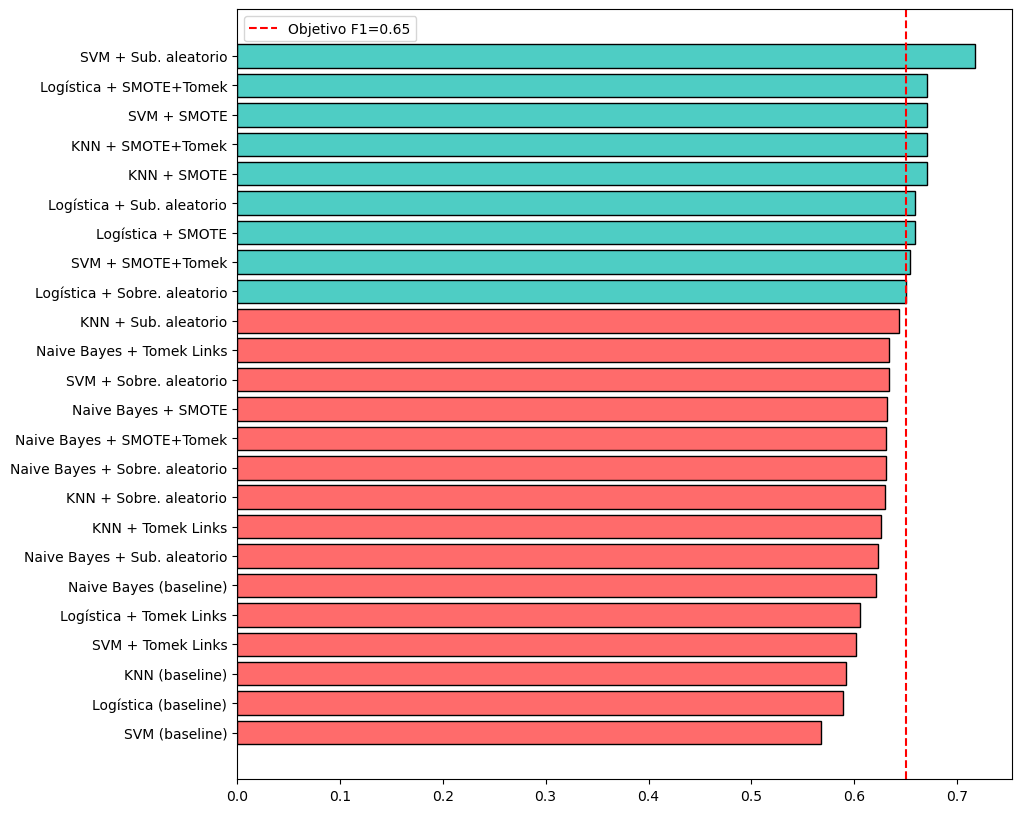

In [97]:
# TODO: Crear gráfico de barras horizontales con F1-Score
#
# Pista:
df_sorted = df_todos.sort_values('F1 (1)')
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#4ECDC4' if v >= F1_OBJETIVO else '#FF6B6B' for v in df_sorted['F1 (1)']]
ax.barh(df_sorted['Modelo'], df_sorted['F1 (1)'], color=colors, edgecolor='black')
ax.axvline(x=F1_OBJETIVO, color='red', linestyle='--', label=f'Objetivo F1={F1_OBJETIVO}')
ax.legend()
plt.show()


### 8.2 Matrices de confusión

**Guía:** Comparar la matriz de confusión del **mejor baseline** vs la **mejor configuración con remuestreo**. Observar cómo cambian los falsos negativos (diabéticas no detectadas).

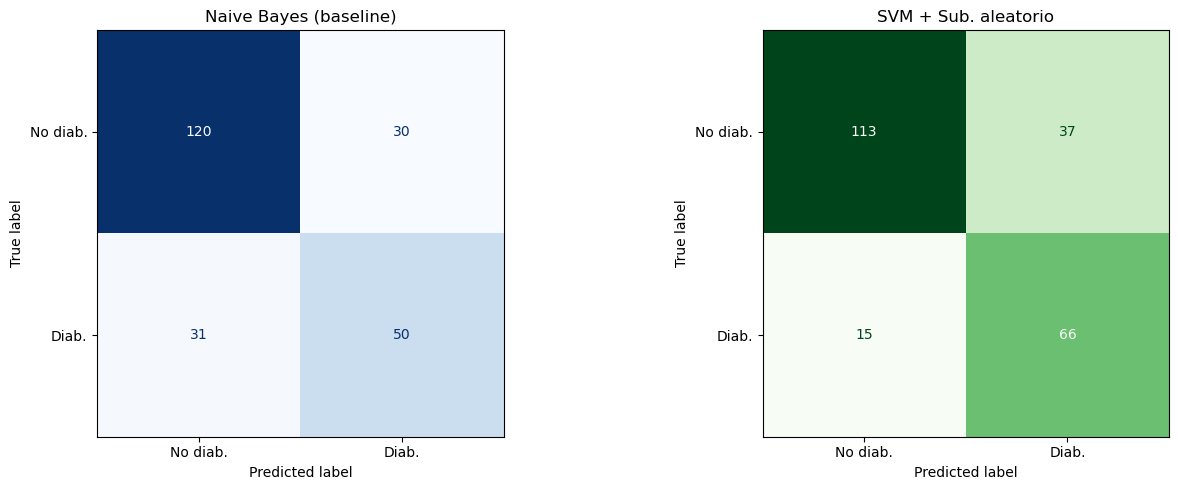

In [98]:
# TODO: Mostrar matrices de confusión comparativas
#
# Pista: Reentrenar el mejor baseline y la mejor config con remuestreo,
# obtener predicciones, y usar ConfusionMatrixDisplay
#
modelo_baseline = GaussianNB()
modelo_baseline.fit(X_train_scaled, y_train)
y_pred_mejor_baseline = modelo_baseline.predict(X_test_scaled)

modelo_rus = SVC(random_state=42)
modelo_rus.fit(X_train_rus, y_train_rus)
y_pred_mejor_remuestreo = modelo_rus.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mejor_baseline,
    display_labels=['No diab.', 'Diab.'],
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title('Naive Bayes (baseline)')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mejor_remuestreo,
    display_labels=['No diab.', 'Diab.'],
    ax=axes[1],
    cmap='Greens',
    colorbar=False
)
axes[1].set_title('SVM + Sub. aleatorio')

plt.tight_layout()
plt.show()


### 8.3 Heatmap comparativo (opcional)

**Guía:** Crear un heatmap donde las filas sean las combinaciones y las columnas las métricas.

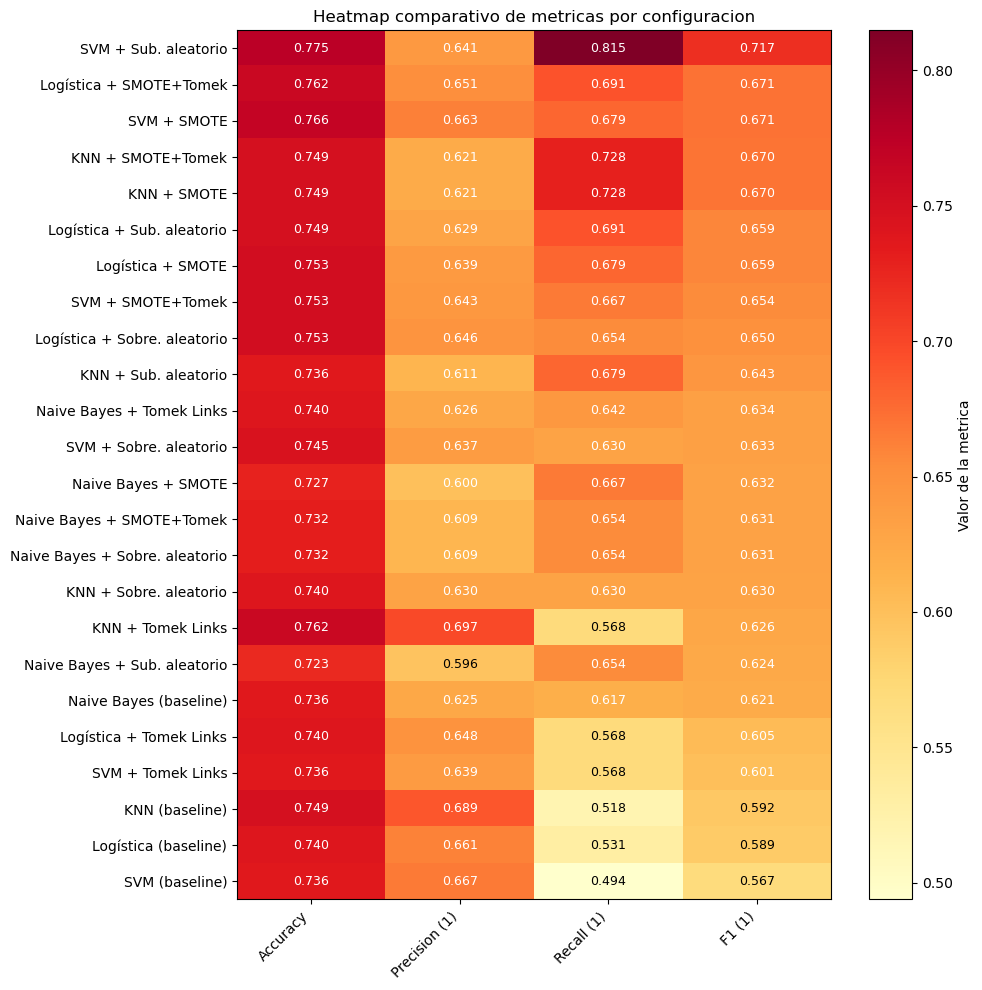

In [99]:
# TODO (opcional): Crear un heatmap con todas las métricas
#
# Pista:
data = df_todos.set_index('Modelo')[['Accuracy', 'Precision (1)', 'Recall (1)', 'F1 (1)']]
data = data.sort_values('F1 (1)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(data.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(data.columns)))
ax.set_xticklabels(data.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(len(data.index)))
ax.set_yticklabels(data.index)
ax.set_title('Heatmap comparativo de metricas por configuracion')

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        valor = data.iloc[i, j]
        color = 'white' if valor >= 0.6 else 'black'
        ax.text(j, i, f'{valor:.3f}', ha='center', va='center', color=color, fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Valor de la metrica')

plt.tight_layout()
plt.show()


---
## Fase 9: Impacto del muestreo según el clasificador

El efecto del muestreo **no es igual para todos los clasificadores**. Analicen la siguiente tabla y contrasten con sus resultados experimentales:

| Clasificador | Efecto positivo del muestreo | Efecto negativo del muestreo |
|---|---|---|
| **Regresión logística** | Mejora recall cuando no se dispone de `class_weight` | Distorsiona las probabilidades calibradas; requiere recalibración |
| **SVM** | Submuestreo reduce el costo O(N²–N³); mejora la frontera | Sobremuestreo duplica vectores de soporte idénticos sin beneficio |
| **k-NN** | Submuestreo reduce el ruido de la clase mayoritaria en la vecindad | Sobremuestreo crea vecindarios densos artificiales; sesga las votaciones |
| **Naive Bayes** | Puede mejorar con desbalance extremo | Altera las frecuencias a priori P(Y=k); las estimaciones se sesgan |

---
## Fase 10: Análisis y discusión

Responder las siguientes preguntas con base en los resultados obtenidos. Cada respuesta debe estar fundamentada con evidencia de los experimentos.

### Preguntas obligatorias

**P1: ¿Qué combinación (remuestreo + clasificador) obtuvo el mejor F1 sobre la clase diabética? ¿Por qué creen que fue la mejor?**

*Respuesta:*
La mejor combinación fue SVM + submuestreo aleatorio, con F1 = 0.7174. También logró recall = 0.8148, el más alto entre todas las configuraciones. Probablemente funcionó mejor porque el submuestreo redujo el sesgo hacia la clase mayoritaria y permitió a SVM separar mejor ambas clases.


**P2: Comparen el efecto del submuestreo (aleatorio, Tomek Links) vs el sobremuestreo (aleatorio, SMOTE). ¿Cuál funcionó mejor en general? ¿Qué fortalezas y debilidades observaron en cada enfoque?**

*Pista: Consideren la cantidad de datos de entrenamiento resultante, la pérdida de información, y el efecto sobre cada métrica.*

*Respuesta:*
En general, funcionaron mejor el submuestreo aleatorio y SMOTE. Tomek Links tuvo mejoras más pequeñas, mientras que el sobremuestreo aleatorio ayudó, pero menos que SMOTE. La fortaleza del submuestreo fue mejorar bastante el recall y el F1, aunque pierde datos; la de SMOTE fue generar ejemplos sintéticos útiles sin eliminar observaciones.


**P3: ¿Hubo algún clasificador que se benefició más del remuestreo? ¿Alguno que empeoró? Expliquen con base en la tabla de la Fase 9.**

*Pista: Piensen en cómo cada clasificador construye su frontera de decisión:*
- *KNN: basado en vecindad local → el submuestreo reduce el ruido de la clase mayoritaria en la vecindad*
- *Regresión Logística: estima P(Y|X) directamente → el muestreo puede distorsionar las probabilidades*
- *SVM: maximiza el margen → el sobremuestreo duplica vectores de soporte sin beneficio*
- *Naive Bayes: basado en probabilidades a priori → el muestreo altera P(Y=k)*

*Respuesta:*
El modelo que más se benefició fue*SVM, que pasó de F1 = 0.5674 en baseline a 0.7174 con submuestreo aleatorio. KNN también mejoró con SMOTE, llegando a 0.6705. En cambio, Naive Bayes mejoró poco con remuestreo y se mantuvo cerca de su baseline, mientras que regresión Logística mejoró de forma más estable pero sin ser la mejor.


**P4: ¿Qué diferencia observaron entre SMOTE y el sobremuestreo aleatorio? ¿Y entre el submuestreo aleatorio y Tomek Links?**


*Respuesta:*
SMOTE fue mejor que el sobremuestreo aleatorio porque generó datos sintéticos más útiles; por ejemplo, con SVM obtuvo F1 = 0.6707 frente a 0.6335 del sobremuestreo aleatorio. Entre submuestreo aleatorio y Tomek Links, el submuestreo aleatorio tuvo un impacto mucho mayor; Tomek Links limpió la frontera, pero no produjo mejoras tan grandes.


**P5: ¿Qué impacto tuvo el remuestreo sobre el accuracy? ¿Por qué el accuracy puede ser engañoso en datasets desbalanceados?**

*Respuesta:*
El remuestreo no siempre redujo el accuracy; en varios casos lo mantuvo o incluso lo mejoró. El mejor caso fue SVM + submuestreo aleatorio, con accuracy = 0.7749. Aun así, el accuracy puede ser engañoso en datos desbalanceados porque un modelo puede acertar muchos casos de la clase mayoritaria y seguir fallando en detectar suficientes pacientes diabéticas.


**P6: En el contexto médico de este dataset, ¿qué es más grave: un falso positivo (diagnosticar diabetes a alguien sano) o un falso negativo (no detectar diabetes)? ¿Cómo afecta esto a la elección de métrica y de técnica de muestreo?**

*Respuesta:*
En este problema es más grave un falso negativo, porque significa no detectar una paciente con diabetes. Por eso conviene priorizar recall y F1-score sobre accuracy. También tiene sentido preferir técnicas de muestreo que mejoren la detección de la clase minoritaria, como el submuestreo aleatorio o SMOTE.


## Fase 11: Conclusiones

**Guía:** Redacten al menos 4 conclusiones que sinteticen lo aprendido en esta práctica. Relacionen sus hallazgos con los conceptos teóricos vistos en las sesiones de submuestreo, sobremuestreo y SMOTE.

**Conclusiones:**

1. El mejor resultado del experimento fue SVM + submuestreo aleatorio, con F1 = 0.7174, superando el objetivo de 0.65.
2. Ningún modelo baseline alcanzó la meta; el mejor fue Naive Bayes, con F1 = 0.6211, lo que confirma el efecto del desbalance.
3. SMOTE fue el sobremuestreo más efectivo, ya que en general rindió mejor que el sobremuestreo aleatorio y mejoró el recall de la clase minoritaria.
4. En un contexto médico, conviene priorizar recall y F1-score, porque detectar más casos positivos es más importante que maximizar solo el accuracy.